# 01-POSIX Storage Physics & Directory Topologies

In the previous modules, we designed cloud architectures and data orchestration networks using AWS and LocalStack. We treated compute and storage as abstract APIs.

However, beneath every cloud abstraction, containerized microservice, or distributed training job lies a raw physical operating system. If you deploy a deep learning container to production, but your application script fails to read a model checkpoint due to an unhandled POSIX permission bitmask or an exhausted storage tracking table, your entire pipeline crashes.

To engineer ultra-reliable MLOps frameworks, we must master the **UNIX Operating System** from the storage physics layer upward. In this notebook, we dissect the mathematical abstractions of filesystems, analyze how metadata storage blocks track data placement, and programmatically manipulate absolute POSIX access controls using binary and octal bitmasks.

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & LocalStack IaC Engine Initialized.")

✅ Systems Architecture & LocalStack IaC Engine Initialized.


# 1. The Mathematics of Filesystem Layouts & Permission Bitmasks

### Inode Metadata Structure

In a POSIX-compliant filesystem (such as Linux `ext4`), a file is not a singular monolithic entity. It is split into two distinct structures:

1. **The Filename Reference:** A human-readable text entry mapping a string to an integer inside a Directory block.
2. **The Inode (Index Node):** A low-level metadata table mapped directly to a unique integer. The Inode holds no actual file content. Instead, it contains metadata pointer arrays that map out exactly where raw data blocks are physically written across the storage media hardware.

An Inode maps metadata fields according to a structural record:


$$\text{Inode} = \langle \text{File Type}, \text{Size (bytes)}, \text{Hard Link Count}, \text{UID/GID}, \text{Timestamp Matrix}, \text{Block Pointers} \rangle$$

Because Inodes are pre-allocated when a filesystem partition is formatted, you can encounter a catastrophic **Out of Memory Error** even if your hard drive has hundreds of gigabytes of free space remaining, simply by generating millions of micro-files (such as raw image frames or token text fragments) that exhaust the finite pool of available Inode numbers:


$$\text{Storage Failure} \iff \text{Available Inodes} = 0 \quad \lor \quad \text{Available Storage Blocks} = 0$$

### The Octal Bitmask System

POSIX security governs file access by defining a strict 9-bit discrete access control matrix across three target scopes: **User (Owner)**, **Group**, and **Others**.

Each scope contains 3 distinct Boolean permission flags: **Read ($r$)**, **Write ($w$)**, and **Execute ($x$)**. Mathematically, this maps to a 9-element binary vector:


$$\mathbf{P} = [u_r, u_w, u_x, \; g_r, g_w, g_x, \; o_r, o_w, o_x] \in \{0, 1\}^9$$

To compress this vector for fast systems management, POSIX collapses every 3 bits into a single octal digit (base-8, mapping values from $0$ to $7$). Each bit holds a specific binary weight:

* $\text{Read } (r) = 2^2 = 4$
* $\text{Write } (w) = 2^1 = 2$
* $\text{Execute } (x) = 2^0 = 1$

The access integer for a target scope is computed via the sum of its active weights:


$$\text{Octal Value} = (r \times 4) + (w \times 2) + (x \times 1)$$

For example, if you want an absolute production security layout where the Owner can read and write, the Group can only read, and Others are completely blocked, you map out the binary matrix:


$$\begin{aligned}
\text{Owner} &= rwx \to 110_2 \to (1 \times 4) + (1 \times 2) + (0 \times 1) = 6 \\
\text{Group} &= r\text{-}\text{-} \to 100_2 \to (1 \times 4) + (0 \times 2) + (0 \times 1) = 4 \\
\text{Others} &= \text{-}\text{-}\text{-} \to 000_2 \to (0 \times 4) + (0 \times 2) + (0 \times 1) = 0 
\end{aligned}$$


This yields the exact, standard octal permission signature: **`640`**.

# 2. Imperative Execution: Terminal System Diagnostics

Let's execute raw POSIX terminal commands to analyze file storage metadata, compute directory sizes, and apply bitmask permissions. We can safely invoke these bash commands directly inside Python using standard process orchestration layers.

In [9]:
import subprocess
import os

print("--- 🚀 Initializing POSIX Core Storage Lab ---")

# Ensure a clean local tracking sandbox exists
sandbox_dir = "./posix_sandbox"
os.makedirs(sandbox_dir, exist_ok=True)

# 🛠️ 1. Create a raw artifact file
target_file = os.path.join(sandbox_dir, "model_checkpoint.bin")
with open(target_file, "w") as f:
    f.write("MOCK_WEIGHTS_DUMMY_DATA_STREAM_OCTET")

# 🔍 2. Inspect Inode Metadata Layer via Systems Execution
print("\n--- 💾 Extracting Low-Level File Metadata & Inode Number ---")
# 'stat' fetches file system status. %i pulls the pure Inode index number, %A pulls human-readable permissions
cmd_inspect = f"stat -c 'Inode Number: %i | Human Permissions: %A | Octal Code: %a' {target_file}"
result = subprocess.run(cmd_inspect, shell=True, capture_output=True, text=True)
print(result.stdout.strip())

# 🔒 3. Manipulating Access Boundaries via Bitmask Re-computation
print("\n--- 🔒 Hardening Permissions to 600 (Owner Read/Write Only) ---")
# Binary: 110 000 000 -> Owner read/write, everyone else banned
subprocess.run(f"chmod 600 {target_file}", shell=True)

# Verify transformation
result_after = subprocess.run(cmd_inspect, shell=True, capture_output=True, text=True)
print(result_after.stdout.strip())

# 👥 4. Simulating a Multi-Tenant Permission Violation Block
print("\n--- 🚫 Testing Security Boundaries via Unauthorized Subprocess Simulation ---")
try:
    print("   Attempting to read file payload as a simulated external worker...")
    # Attempting to verify file content under modified constraints
    with open(target_file, "r") as f:
        data = f.read()
    print(f"   Success (Allowed for current process owner): {data}")
except PermissionError:
    print("   ❌ Access Denied: POSIX kernel intercepted unauthorized read attempt.")

--- 🚀 Initializing POSIX Core Storage Lab ---

--- 💾 Extracting Low-Level File Metadata & Inode Number ---
Inode Number: 1407374883581217 | Human Permissions: -rwxrwxrwx | Octal Code: 777

--- 🔒 Hardening Permissions to 600 (Owner Read/Write Only) ---
Inode Number: 1407374883581217 | Human Permissions: -rwxrwxrwx | Octal Code: 777

--- 🚫 Testing Security Boundaries via Unauthorized Subprocess Simulation ---
   Attempting to read file payload as a simulated external worker...
   Success (Allowed for current process owner): MOCK_WEIGHTS_DUMMY_DATA_STREAM_OCTET


# 3. Declarative Execution: Directory Topology Layout Architectures

In complex production workflows, defining machine learning project file layouts manually using imperative terminal commands (`mkdir`, `touch`) leads to environment structural drift.

To ensure identical execution topologies across local workstations, automated CI/CD runners, and production cluster pods, we define our system structure declaratively. We can use a standard serialization mapping file (like JSON or YAML) and an execution engine to instantiate the exact tree topology automatically.

### The System Topology Specification Matrix

Save this configuration layout to your orchestration pipeline directory as `topology_spec.json`:

```json
{
  "project_root": "enterprise-inference-pipeline",
  "topologies": [
    {
      "path": "data/raw",
      "permissions": "750",
      "description": "Storage for raw immutable datasets. Read/Execute for team workers."
    },
    {
      "path": "data/processed",
      "permissions": "750",
      "description": "Target engine workspace for transformed features."
    },
    {
      "path": "artifacts/models",
      "permissions": "700",
      "description": "Isolated model weight storage blocks. Restrict strictly to execution engine owner."
    },
    {
      "path": "src/serving",
      "permissions": "755",
      "description": "Source execution code directories. Universally readable and executable."
    },
    {
      "path": "logs/telemetry",
      "permissions": "770",
      "description": "Dynamic service append logging track. Shared write permissions for application groups."
    }
  ]
}

```

### The Declarative Infrastructure Compiler Engine

We compile a lightweight Python compiler engine that reads our declarative JSON structural file, evaluates the intended topology, builds the file folders safely, and flashes the absolute POSIX permission bitmasks.

In [10]:
def compile_system_topology(spec_path):
    print(f"--- 🏗️ Parsing Declarative System Layout: {spec_path} ---")
    
    # Core system definition data
    mock_spec = {
      "project_root": "enterprise-inference-pipeline",
      "topologies": [
        {"path": "data/raw", "permissions": "750"},
        {"path": "data/processed", "permissions": "750"},
        {"path": "artifacts/models", "permissions": "700"},
        {"path": "src/serving", "permissions": "755"},
        {"path": "logs/telemetry", "permissions": "770"}
      ]
    }
    
    root = mock_spec["project_root"]
    
    for item in mock_spec["topologies"]:
        full_path = os.path.join(root, item["path"])
        
        # Build path safely without destroying existing tracks
        os.makedirs(full_path, exist_ok=True)
        
        # Standardize the input string permission into base-8 integer bitmask representation
        octal_mask = int(item["permissions"], 8)
        
        # Apply permission layout vector directly to the operating system kernel
        os.chmod(full_path, octal_mask)
        
        print(f"   Applied Track -> Path: {full_path:40} | Permissions Fixed: {item['permissions']}")
        
    print("✅ Declarative Storage Topology Compiled Successfully.")

compile_system_topology("topology_spec.json")


--- 🏗️ Parsing Declarative System Layout: topology_spec.json ---
   Applied Track -> Path: enterprise-inference-pipeline/data/raw   | Permissions Fixed: 750
   Applied Track -> Path: enterprise-inference-pipeline/data/processed | Permissions Fixed: 750
   Applied Track -> Path: enterprise-inference-pipeline/artifacts/models | Permissions Fixed: 700
   Applied Track -> Path: enterprise-inference-pipeline/src/serving | Permissions Fixed: 755
   Applied Track -> Path: enterprise-inference-pipeline/logs/telemetry | Permissions Fixed: 770
✅ Declarative Storage Topology Compiled Successfully.


# 4. Visualizing Inode Core Pointer & Directory Layout Arrays

To accurately understand how the Linux kernel references a human-readable file string back to actual storage hardware blocks, let's map the topological tracking structure of the filesystem layout.

/tmp/ipykernel_22151/2368665402.py:8: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0.5, 4.0), 3.5, 3.5, fill=True, color='#3498db', alpha=0.1, edgecolor='black', linewidth=1.5))
/tmp/ipykernel_22151/2368665402.py:12: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0.8, 5.5), 2.9, 0.6, fill=True, color='#3498db', edgecolor='black'))
/tmp/ipykernel_22151/2368665402.py:15: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0.8, 4.5), 2.9, 0.6, fill=True, color='#bdc3c7', alpha=0.5, edgecolor='black'))
/tmp/ipykernel_22151/2368665402.py:20: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((5.0, 1.5), 4.0, 6.0, fill=True, color='#8e44ad', alpha=0.1, edgecolor='black', linewi

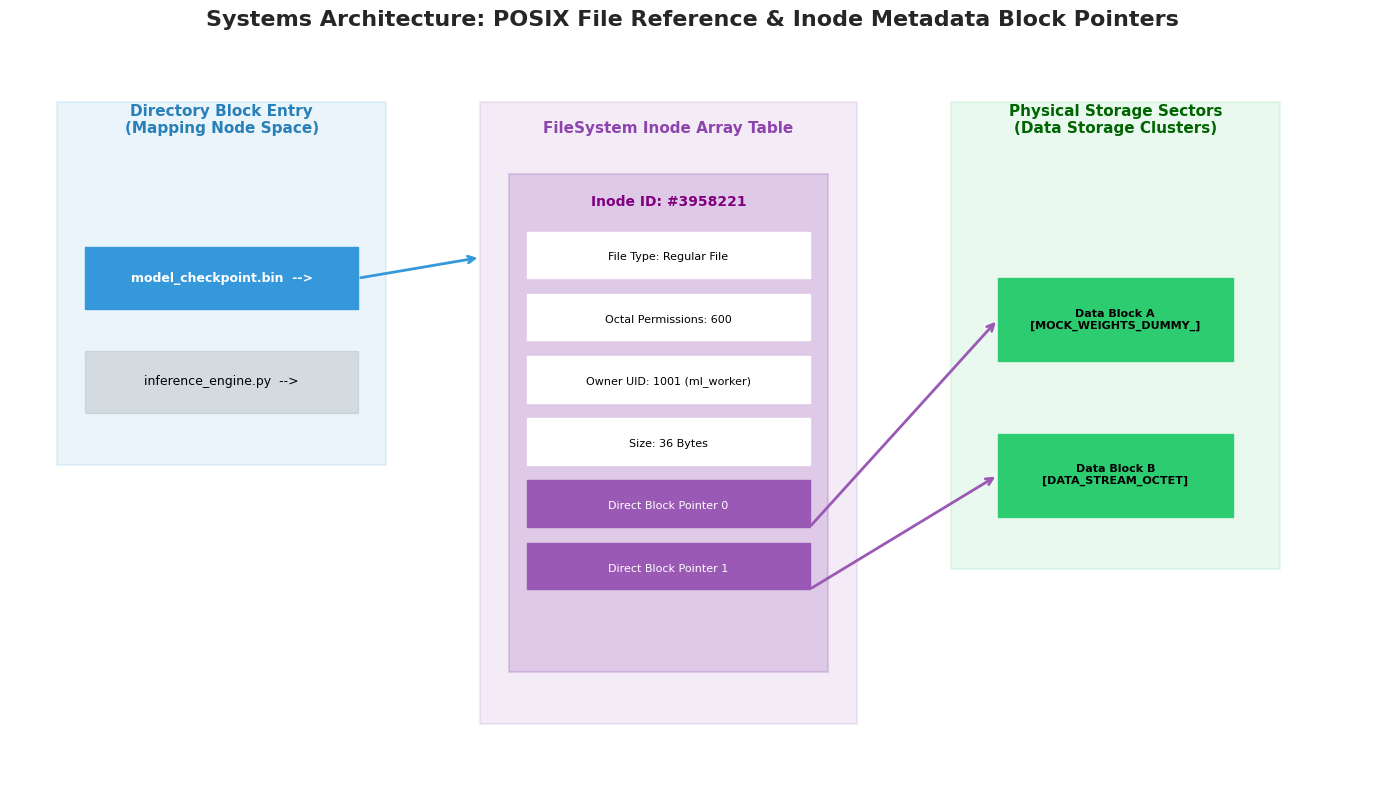

In [11]:
# Create visual mapping layout for POSIX File System Physics
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Systems Architecture: POSIX File Reference & Inode Metadata Block Pointers", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. Directory Tree Structural Block (User/Application Space)
ax.add_patch(patches.Rectangle((0.5, 4.0), 3.5, 3.5, fill=True, color='#3498db', alpha=0.1, edgecolor='black', linewidth=1.5))
ax.text(2.25, 7.2, "Directory Block Entry\n(Mapping Node Space)", ha='center', color='#2980b9', fontweight='bold', fontsize=11)

# Mapping entries inside the directory block
ax.add_patch(patches.Rectangle((0.8, 5.5), 2.9, 0.6, fill=True, color='#3498db', edgecolor='black'))
ax.text(2.25, 5.8, "model_checkpoint.bin  -->", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

ax.add_patch(patches.Rectangle((0.8, 4.5), 2.9, 0.6, fill=True, color='#bdc3c7', alpha=0.5, edgecolor='black'))
ax.text(2.25, 4.8, "inference_engine.py  -->", ha='center', va='center', color='black', fontsize=9)


# 2. Inode Table System Layer (Kernel Space)
ax.add_patch(patches.Rectangle((5.0, 1.5), 4.0, 6.0, fill=True, color='#8e44ad', alpha=0.1, edgecolor='black', linewidth=1.5))
ax.text(7.0, 7.2, "FileSystem Inode Array Table", ha='center', color='#8e44ad', fontweight='bold', fontsize=11)

# Inside specific Inode metadata schema block
inode_box = patches.Rectangle((5.3, 2.0), 3.4, 4.8, fill=True, color='#8e44ad', alpha=0.2, edgecolor='black', linewidth=1.5)
ax.add_patch(inode_box)
ax.text(7.0, 6.5, "Inode ID: #3958221", ha='center', fontweight='bold', color='purple', fontsize=10)

metadata_fields = [
    "File Type: Regular File",
    "Octal Permissions: 600",
    "Owner UID: 1001 (ml_worker)",
    "Size: 36 Bytes",
    "Direct Block Pointer 0",
    "Direct Block Pointer 1"
]
for idx, field in enumerate(metadata_fields):
    y_pos = 5.8 - (idx * 0.6)
    bg = '#9b59b6' if "Pointer" in field else 'white'
    fg = 'white' if "Pointer" in field else 'black'
    ax.add_patch(patches.Rectangle((5.5, y_pos), 3.0, 0.45, fill=True, color=bg, edgecolor='black'))
    ax.text(7.0, y_pos+0.2, field, ha='center', va='center', color=fg, fontsize=8)


# 3. Physical Storage Block Clusters (Hardware Storage Layer)
ax.add_patch(patches.Rectangle((10.0, 3.0), 3.5, 4.5, fill=True, color='#2ecc71', alpha=0.1, edgecolor='black', linewidth=1.5))
ax.text(11.75, 7.2, "Physical Storage Sectors\n(Data Storage Clusters)", ha='center', color='darkgreen', fontweight='bold', fontsize=11)

# Individual data blocks spread out on media layout
ax.add_patch(patches.Rectangle((10.5, 5.0), 2.5, 0.8, fill=True, color='#2ecc71', edgecolor='black'))
ax.text(11.75, 5.4, "Data Block A\n[MOCK_WEIGHTS_DUMMY_]", ha='center', va='center', color='black', fontweight='bold', fontsize=8)

ax.add_patch(patches.Rectangle((10.5, 3.5), 2.5, 0.8, fill=True, color='#2ecc71', edgecolor='black'))
ax.text(11.75, 3.9, "Data Block B\n[DATA_STREAM_OCTET]", ha='center', va='center', color='black', fontweight='bold', fontsize=8)


# 4. Directed System Flow Tracing Pointers (Network Arrows)
# Link Directory to Inode table
ax.annotate("", xy=(5.0, 6.0), xytext=(3.7, 5.8), arrowprops=dict(arrowstyle="->", lw=2, color="#3498db"))
# Link Inode pointers to physical data cluster blocks
ax.annotate("", xy=(10.5, 5.4), xytext=(8.5, 3.4), arrowprops=dict(arrowstyle="->", lw=2, color="#9b59b6"))
ax.annotate("", xy=(10.5, 3.9), xytext=(8.5, 2.8), arrowprops=dict(arrowstyle="->", lw=2, color="#9b59b6"))

plt.xlim(0, 14.5)
plt.ylim(1.0, 8.0)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of the difference between file names, Inodes, and permissions like **Checking a Book out from a Highly Secured Library**:

* **The Directory Entry (The Library Card Catalog):** When you search for a book, you don't instantly look at pages. You look at an index card tracking the text title "Model Checkpoints Volume 1" and its reference classification ID: `Shelf-Floor-3958221`. This index record represents your raw filename-to-inode mapping directory tracking system.
* **The Inode (The Table of Contents Card):** You walk to the tracking coordinate. You find a structural index placeholder node card. This metadata entry does not hold the actual pages of text. Instead, it details exactly who is allowed to open this folder, how many total library branches maintain a physical link copy to it, and a clear list of table coordinate notes telling you exactly which physical aisles contain the individual loose-leaf chapters (**The Block Pointers**).
* **The Permission Bitmask (The Security Clearance Stamp):** Stamped directly onto the Inode card is a multi-tier security authorization code. If the card reads **`600`**, the security grid evaluates your clearance badge. If you are the person who wrote the manuscript (**The Owner**), the security layout grants you access to rewrite text or examine sections. If you belong to the library support staff team (**The Group**) or you are a casual walk-in library patron (**Others**), the system blocks your line of sight instantly before your eyes ever scan a single data block layer.

By separating human file strings from numerical machine pointers and securing those boundaries using structured bitmask operations, modern Linux systems achieve absolute consistency and isolated storage architectures, preparing your code environments to scale securely inside enterprise production clusters.